# RED NEURONAL CONVOLUCIONAL PARA CLASIFICACIÓN DE IMAGENES DE PERROS Y GATOS
# APLICANDO DATA AUGMENTATION
## DATASET [KAGGLE](https://www.kaggle.com/competitions/dogs-vs-cats/overview)

# 1 - GARGAMOS IMAGENES PARA EL DATASET

## IMPORTAMOS LIBRERIAS

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## CARGAMOS PATH DE IMAGENES

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
import os
base_dir = '/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir,'validation')
test_dir = os.path.join(base_dir,'test')
print(train_dir)
print(validation_dir)
print(test_dir)

/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/train
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/validation
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/test


## CREO LOS DIRECTORIOS PARA CADA CONJUNTO DE DATOS DE PERROS Y GATOS

In [8]:
train_gatos_dir = os.path.join(train_dir, 'gatos')
train_perros_dir = os.path.join(train_dir, 'perros')

validation_gatos_dir = os.path.join(validation_dir, 'gatos')
validation_perros_dir = os.path.join(validation_dir, 'perros')

test_gatos_dir = os.path.join(test_dir, 'gatos')
test_perros_dir = os.path.join(test_dir, 'perros')

print(train_gatos_dir)
print(train_perros_dir)
print(validation_gatos_dir)
print(validation_perros_dir)
print(test_gatos_dir)
print(test_perros_dir)

/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/train/gatos
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/train/perros
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/validation/gatos
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/validation/perros
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/test/gatos
/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/test/perros


# 2 - EJEMPLO DE DATA AUGMENTATION

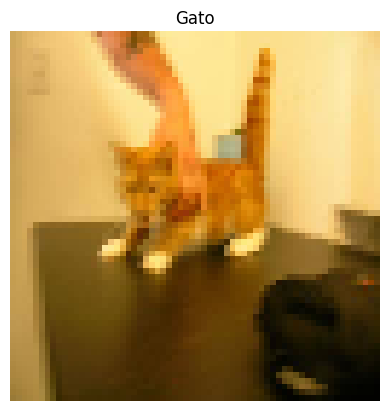

In [12]:
from tensorflow.keras.preprocessing import image
img = image.load_img('/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/train/gatos/cat.0.jpg',target_size=(64,64))
plt.imshow(img)
plt.title('Gato')
plt.axis('off')
plt.show()

# CREAMOS UN OBJETO QUE APLIQUE DATA AUGMENTATION

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
augmented_data = ImageDataGenerator(rescale=1. /255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)

## PARAMETROS PARA GENERAR DATA AUGMENTATION

## Parámetros de Augmentación de Imágenes

### `rescale=1./255`
Normaliza los valores de los píxeles dividiéndolos entre 255.  

Las imágenes suelen tener valores en el rango `[0, 255]`, y este parámetro los convierte a un rango `[0, 1]`, lo cual es beneficioso para entrenar redes neuronales.  

### `rotation_range=40`
Rota la imagen aleatoriamente hasta 40 grados en ambas direcciones (sentido horario y antihorario).  

Introduce variabilidad en la orientación de los datos de entrenamiento.  

### `width_shift_range=0.2`
Desplaza la imagen horizontalmente hasta un 20% del ancho de la imagen de forma aleatoria.  

Simula variaciones en la posición de los objetos dentro de la imagen.  

### `height_shift_range=0.2`
Desplaza la imagen verticalmente hasta un 20% de la altura de la imagen de forma aleatoria.  

Similar a `width_shift_range`, pero en la dirección vertical.  

### `shear_range=0.2`
Aplica una transformación de cizallamiento (*shear*), que distorsiona la imagen como si se estuviera viendo desde un ángulo inclinado.  

Introduce variabilidad en la perspectiva.  

### `zoom_range=0.2`
Aplica un zoom aleatorio dentro del rango especificado (20% en este caso).  

Simula variaciones en la distancia del objeto respecto a la cámara.  

### `horizontal_flip=True`
Realiza un espejado horizontal aleatorio (voltea la imagen de izquierda a derecha).  

Útil para imágenes donde la orientación izquierda-derecha no es crucial (por ejemplo, fotos de animales o paisajes).  


# APLICAMOS NUESTRO OBJETO PARA GENERAR IMAGENES ALEATORIAS DE LA IMAGEN DE MUESTRA

In [15]:
from tensorflow.keras.preprocessing import image
img = image.load_img('/content/drive/MyDrive/Colab Notebooks/DEEP-LEARNING/datasets/train/gatos/cat.0.jpg',target_size=(64,64))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

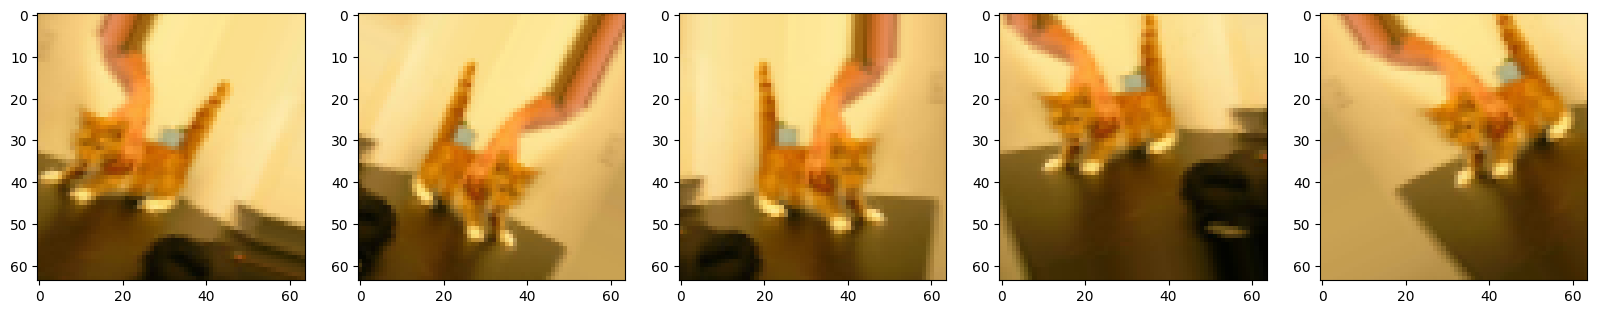

In [16]:
# Generar las imágenes aumentadas
i = 0
fig, ax = plt.subplots(1, 5, figsize=(20, 20))  # Mostrar 5 imágenes aumentadas
for batch in augmented_data.flow(img_array, batch_size=1):
    ax[i].imshow(image.array_to_img(batch[0]))  # Convertir el array a imagen y mostrarla
    i += 1
    if i % 5 == 0:
        break  # Solo mostrar 5 imágenes
plt.show()

# 3 - CREAMOS OBJETOS PARA CARGAR EL CONJUNTO DE ENTRENAMIENTO VALIDACIÓN Y PRUEBAS

In [17]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator(rescale=1. /255,
                                    rotation_range=40,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    shear_range=0.2,
                                    zoom_range=0.2,
                                    horizontal_flip=True)
val_data = ImageDataGenerator(rescale=1. /255)
test_data = ImageDataGenerator(rescale=1. /255)

## CARGAMOS LOS CONJUNTOS DE DATOS CON LOS OBJETOS CREADOS

In [19]:
training_set = train_data.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=32,
    class_mode='binary'
)
validation_set = train_data.flow_from_directory(
    validation_dir,
    target_size=(64,64),
    batch_size=20,
    class_mode='binary'
)
test_set = train_data.flow_from_directory(
    test_dir,
    target_size=(64,64),
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 2 images belonging to 2 classes.


# 4 - CREAMOS MODELO DE RED NEURONAL CONVOLUCIONAL

In [20]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

modelo = Sequential()
modelo.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Conv2D(32,(3,3),activation='relu'))
modelo.add(MaxPooling2D((2,2)))
modelo.add(Flatten())
modelo.add(Dense(128,activation='relu'))
modelo.add(Dropout(0.5))
modelo.add(Dense(1,activation='sigmoid'))

modelo.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
modelo.compile(loss="binary_crossentropy",
               optimizer='adam',
               metrics=['accuracy'])

In [ ]:
history = modelo.fit(training_set,epochs=20,batch_size=100,validation_data=validation_set)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 1011s 16s/step - accuracy: 0.4824 - loss: 0.7104 - val_accuracy: 0.5350 - val_loss: 0.6711
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 200ms/step - accuracy: 0.6170 - loss: 0.6607 - val_accuracy: 0.6630 - val_loss: 0.6134
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.7136 - loss: 0.5707 - val_accuracy: 0.6970 - val_loss: 0.5731
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.7424 - loss: 0.5307 - val_accuracy: 0.7150 - val_loss: 0.5651
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step - accuracy: 0.7828 - loss: 0.4778 - val_accuracy: 0.7260 - val_loss: 0.5403
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 212ms/step - accuracy: 0.7998 - loss: 0.4265 - val_accuracy: 0.7170 - val_loss: 0.5609
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 209ms/step - accuracy: 0.8139 - loss: 0.3931 - val_accuracy: 0.7070 - val_loss: 0.5741
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 206ms/step - accuracy: 0.8630 - loss: 0.3479 - val_accu

# EVALUAMOS EL MODELO

In [ ]:
evaluacion = modelo.evaluate(test_set)
print(evaluacion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step - accuracy: 1.0000 - loss: 0.1113
[0.11129922419786453, 1.0]


# REALIZAMOS PREDICCIÓN DEL MODELO

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
predicción :  [[1.]]
Es un perro


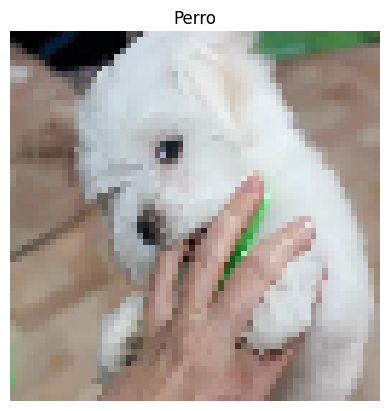

In [ ]:
gato = image.load_img(test_gatos_dir + "/cat.1000.jpg",target_size=(64,64))
perro = image.load_img(test_perros_dir + "/dog.1000.jpg",target_size=(64,64))
conejo = image.load_img('/content/conejo.png',target_size=(64,64))
tigre = image.load_img('/content/tigre.jpg',target_size=(64,64))
perro2 = image.load_img('/content/perro.jpg',target_size=(64,64))
imagen_prueba = perro2


test_image = image.img_to_array(imagen_prueba)
test_image = np.expand_dims(test_image,axis=0)

training_set.class_indices


result = modelo.predict(test_image)
print("predicción : ",result)
if result[0][0] == 0:
  print("Es un gato")
  plt.imshow(imagen_prueba)
  plt.title('Gato')
  plt.axis('off')
  plt.show()
else:
  print("Es un perro")
  plt.imshow(imagen_prueba)
  plt.title('Perro')
  plt.axis('off')
  plt.show()

# GRAFICAMOS ACCURACY Y LOSS

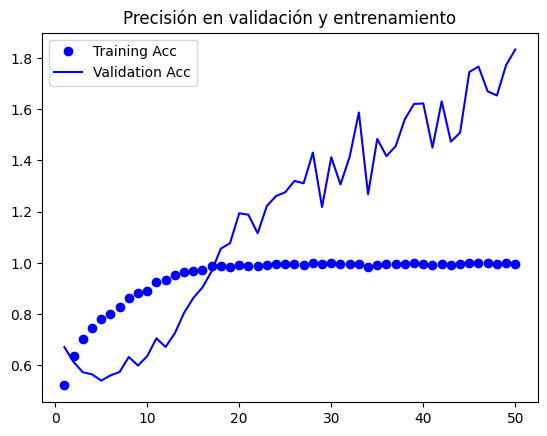

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training Acc')
plt.plot(epochs,val_acc,'b',label='Validation Acc')
plt.title('Precisión en validación y entrenamiento')
plt.legend()
plt.show()

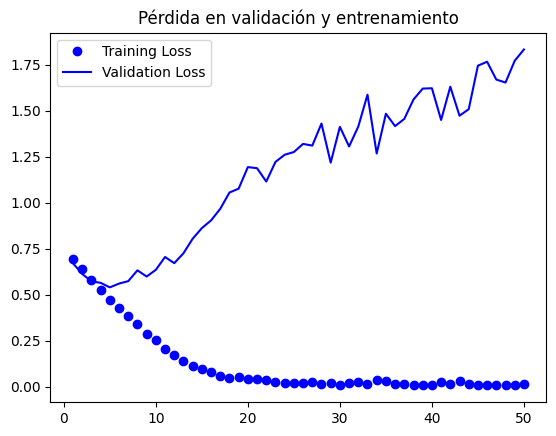

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plt.plot(epochs,loss,'bo',label='Training Loss')
plt.plot(epochs,val_loss,'b',label='Validation Loss')
plt.title('Pérdida en validación y entrenamiento')
plt.legend()
plt.show()


# GUARDAMOS EL MODELO ENTRENADO

In [ ]:
modelo.save("perrosygatos.h5")

In [ ]:
modelo.save("modelo_perrosygatos.keras")

In [ ]:
import keras
red = keras.models.load_model('/content/modelo_perrosygatos.keras')
red

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<Sequential name=sequential, built=True>